In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Part 1: Beggining of the Analysis

In [2]:
data = pd.read_csv("customer_churn_dataset-training-master.csv")
data.head(10)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
5,8.0,51.0,Male,33.0,25.0,9.0,26.0,Premium,Annual,129.0,8.0,1.0
6,9.0,58.0,Female,49.0,12.0,3.0,16.0,Standard,Quarterly,821.0,24.0,1.0
7,10.0,55.0,Female,37.0,8.0,4.0,15.0,Premium,Annual,445.0,30.0,1.0
8,11.0,39.0,Male,12.0,5.0,7.0,4.0,Standard,Quarterly,969.0,13.0,1.0
9,12.0,64.0,Female,3.0,25.0,2.0,11.0,Standard,Quarterly,415.0,29.0,1.0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [4]:
data.describe(include="all")

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832,440832.000000,440832.000000,440832.000000,440832.000000,440832,440832,440832.000000,440832.000000,440832.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,NaN,NaN,NaN
top,NaN,NaN,Male,NaN,NaN,NaN,NaN,Standard,Annual,NaN,NaN,NaN
freq,NaN,NaN,250252,NaN,NaN,NaN,NaN,149128,177198,NaN,NaN,NaN
mean,225398.667955,39.373153,NaN,31.256336,15.807494,3.604437,12.965722,NaN,NaN,631.616223,14.480868,0.567107
std,129531.918550,12.442369,NaN,17.255727,8.586242,3.070218,8.258063,NaN,NaN,240.803001,8.596208,0.495477
min,2.000000,18.000000,NaN,1.000000,1.000000,0.000000,0.000000,NaN,NaN,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,NaN,16.000000,9.000000,1.000000,6.000000,NaN,NaN,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,NaN,32.000000,16.000000,3.000000,12.000000,NaN,NaN,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,NaN,46.000000,23.000000,6.000000,19.000000,NaN,NaN,830.000000,22.000000,1.000000


In [5]:
data.columns = data.columns.str.strip().str.lower().str.replace(" ","_")
data.columns

Index(['customerid', 'age', 'gender', 'tenure', 'usage_frequency',
       'support_calls', 'payment_delay', 'subscription_type',
       'contract_length', 'total_spend', 'last_interaction', 'churn'],
      dtype='object')

In [6]:
print(data["gender"].unique())
print(data["subscription_type"].unique())
print(data["contract_length"].unique())

['Female' 'Male' nan]
['Standard' 'Basic' 'Premium' nan]
['Annual' 'Monthly' 'Quarterly' nan]


In [7]:
data["gender"].isna().sum()

1

In [8]:
data[data["gender"].isna()]

,customerid,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
data = data.dropna()

In [10]:
mapping = {
    "Female" : 0,
    "Male" : 1
}

data["gender"] = data["gender"].map(mapping)
data = pd.get_dummies(data, columns=["subscription_type","contract_length"])

data

,customerid,age,gender,tenure,usage_frequency,support_calls,payment_delay,total_spend,last_interaction,churn,subscription_type_Basic,subscription_type_Premium,subscription_type_Standard,contract_length_Annual,contract_length_Monthly,contract_length_Quarterly
0,2.0,30.0,0,39.0,14.0,5.0,18.0,932.00,17.0,1.0,False,False,True,True,False,False
1,3.0,65.0,0,49.0,1.0,10.0,8.0,557.00,6.0,1.0,True,False,False,False,True,False
2,4.0,55.0,0,14.0,4.0,6.0,18.0,185.00,3.0,1.0,True,False,False,False,False,True
3,5.0,58.0,1,38.0,21.0,7.0,7.0,396.00,29.0,1.0,False,False,True,False,True,False
4,6.0,23.0,1,32.0,20.0,5.0,8.0,617.00,20.0,1.0,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,1,54.0,15.0,1.0,3.0,716.38,8.0,0.0,False,True,False,True,False,False
440829,449996.0,25.0,0,8.0,13.0,1.0,20.0,745.38,2.0,0.0,False,True,False,True,False,False
440830,449997.0,26.0,1,35.0,27.0,1.0,5.0,977.31,9.0,0.0,False,False,True,False,False,True
440831,449998.0,28.0,1,55.0,14.0,2.0,0.0,602.55,2.0,0.0,False,False,True,False,False,True


In [11]:
for column in data.columns:
    data[column] = data[column].astype(int)

data

,customerid,age,gender,tenure,usage_frequency,support_calls,payment_delay,total_spend,last_interaction,churn,subscription_type_Basic,subscription_type_Premium,subscription_type_Standard,contract_length_Annual,contract_length_Monthly,contract_length_Quarterly
0,2,30,0,39,14,5,18,932,17,1,0,0,1,1,0,0
1,3,65,0,49,1,10,8,557,6,1,1,0,0,0,1,0
2,4,55,0,14,4,6,18,185,3,1,1,0,0,0,0,1
3,5,58,1,38,21,7,7,396,29,1,0,0,1,0,1,0
4,6,23,1,32,20,5,8,617,20,1,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995,42,1,54,15,1,3,716,8,0,0,1,0,1,0,0
440829,449996,25,0,8,13,1,20,745,2,0,0,1,0,1,0,0
440830,449997,26,1,35,27,1,5,977,9,0,0,0,1,0,0,1
440831,449998,28,1,55,14,2,0,602,2,0,0,0,1,0,0,1


In [12]:
def determine_outlier_thresholds_iqr(df, col_name, th1=0.25, th3=0.75):
    quartile1 = df[col_name].quantile(th1)
    quartile3 = df[col_name].quantile(th3)
    iqr = quartile3 - quartile1
    upper_limit = quartile3 + 1.5 * iqr
    lower_limit = quartile1 - 1.5 * iqr
    return lower_limit, upper_limit

In [13]:
for column in data.columns:
    lower, upper = determine_outlier_thresholds_iqr(data, column)
    print(f"Lower and upper value for {column} variable: {lower} | {upper}")

Lower and upper value for customerid variable: -222554.5 | 673915.5
Lower and upper value for age variable: 0.5 | 76.5
Lower and upper value for gender variable: -1.5 | 2.5
Lower and upper value for tenure variable: -29.0 | 91.0
Lower and upper value for usage_frequency variable: -12.0 | 44.0
Lower and upper value for support_calls variable: -6.5 | 13.5
Lower and upper value for payment_delay variable: -13.5 | 38.5
Lower and upper value for total_spend variable: -45.0 | 1355.0
Lower and upper value for last_interaction variable: -15.5 | 44.5
Lower and upper value for churn variable: -1.5 | 2.5
Lower and upper value for subscription_type_Basic variable: -1.5 | 2.5
Lower and upper value for subscription_type_Premium variable: -1.5 | 2.5
Lower and upper value for subscription_type_Standard variable: -1.5 | 2.5
Lower and upper value for contract_length_Annual variable: -1.5 | 2.5
Lower and upper value for contract_length_Monthly variable: 0.0 | 0.0
Lower and upper value for contract_length

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


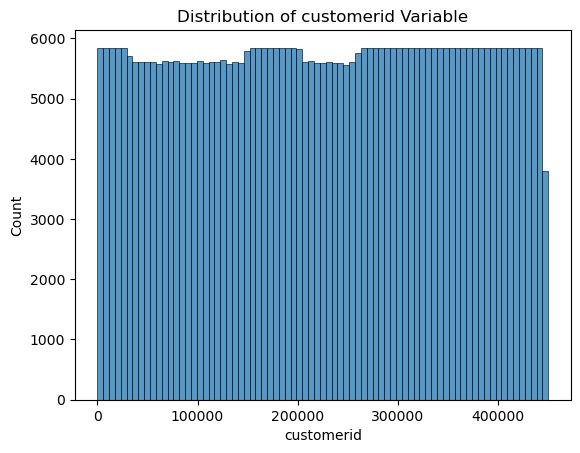

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


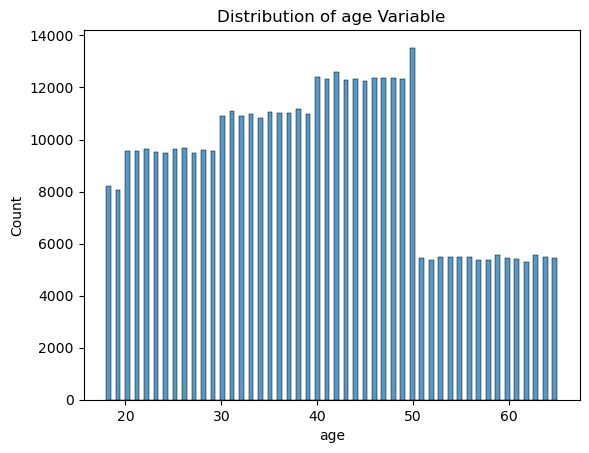

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


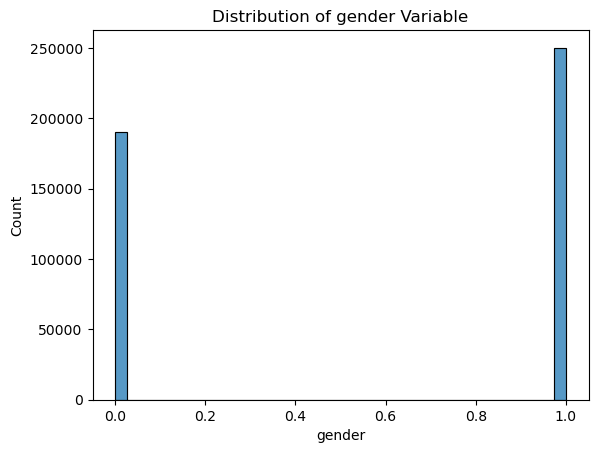

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


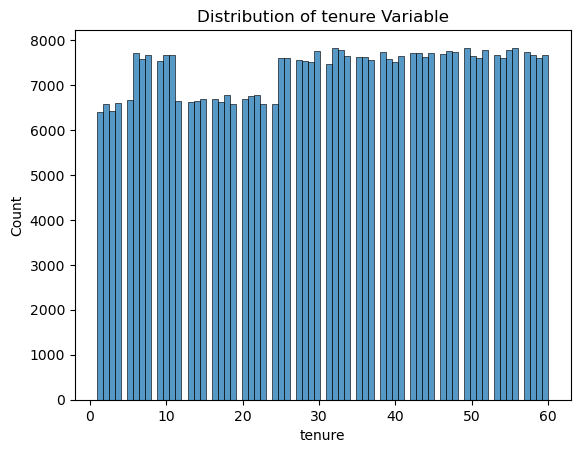

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


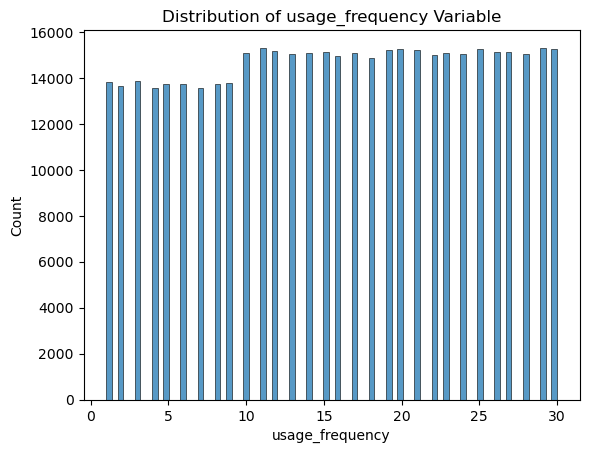

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


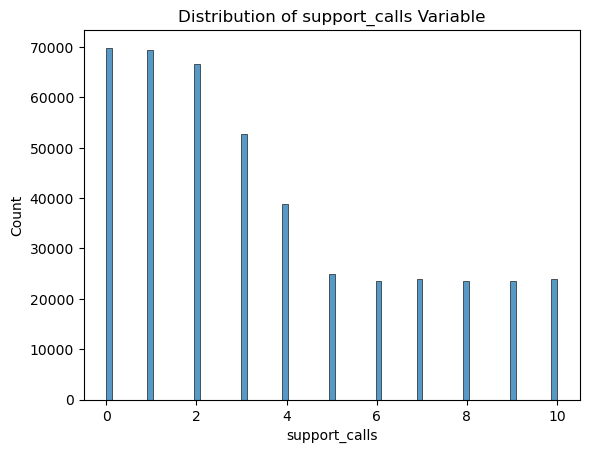

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


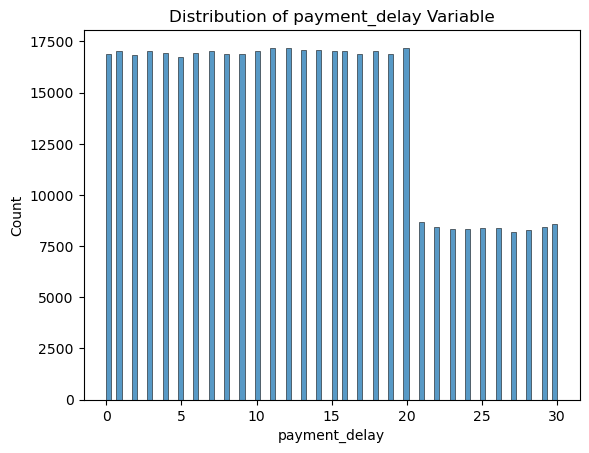

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


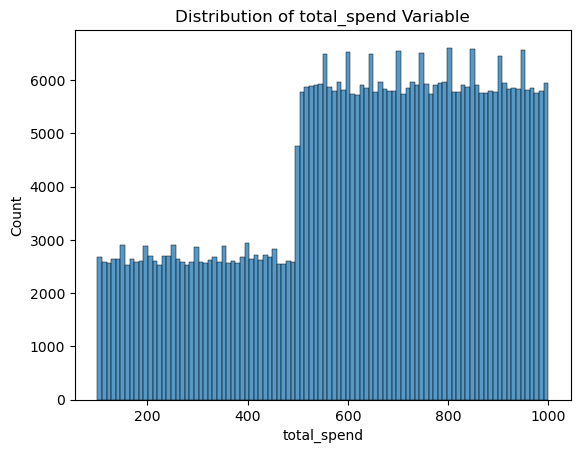

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


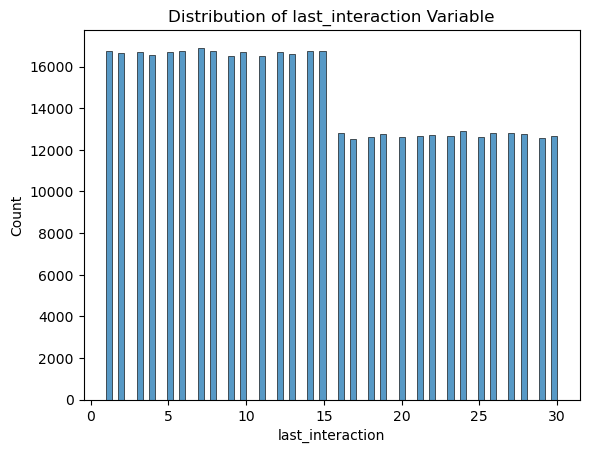

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


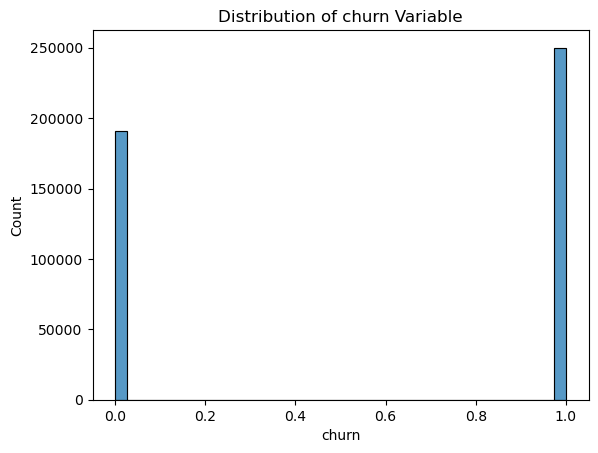

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


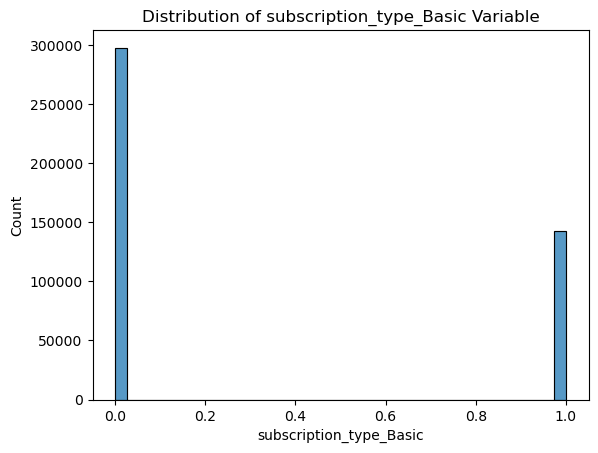

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


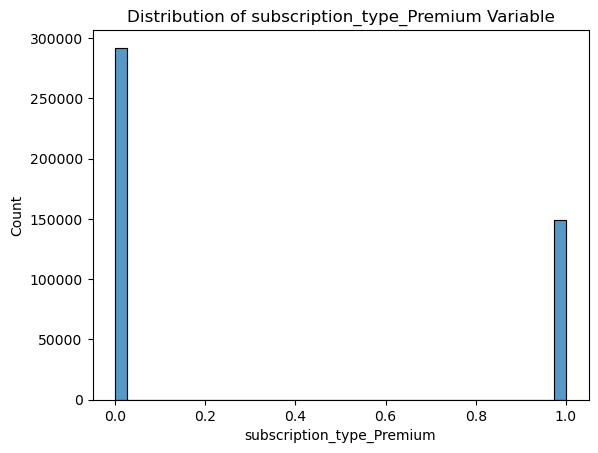

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


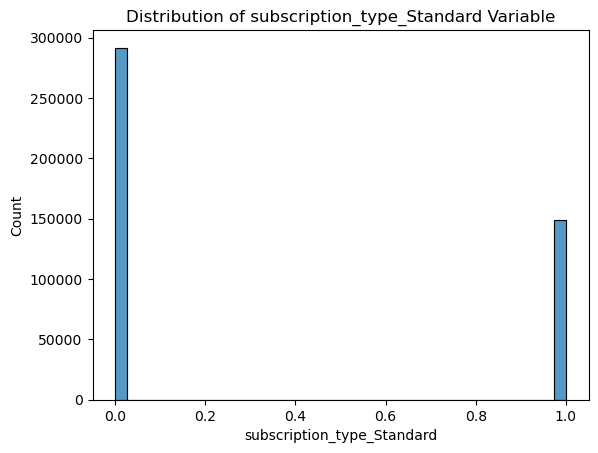

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


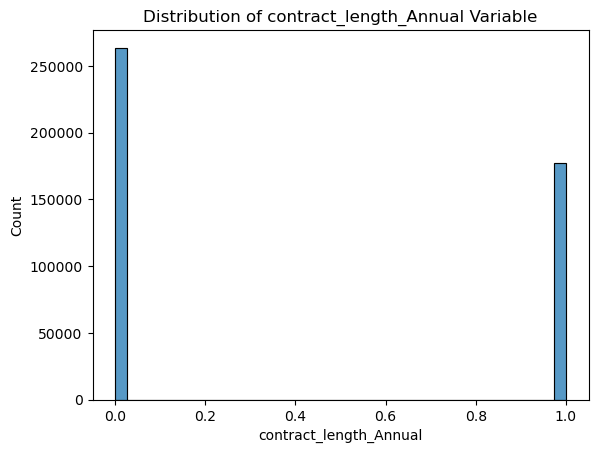

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


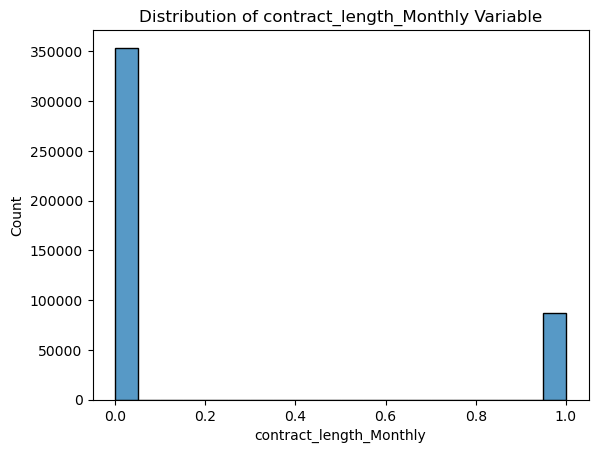

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


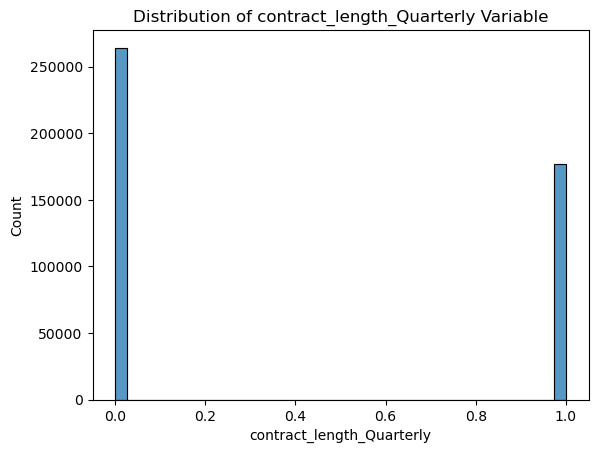

In [14]:
for column in data.columns:
    sns.histplot(
        data = data,
        x = column
    )
    plt.title(f"Distribution of {column} Variable")
    plt.show()

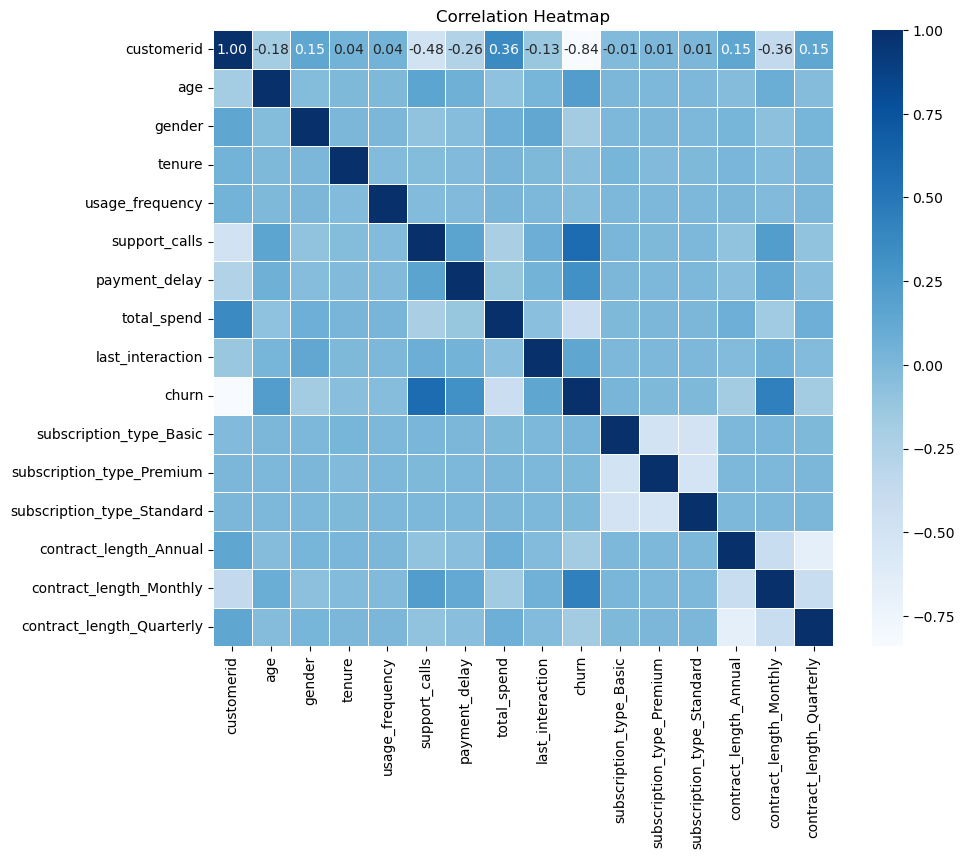

In [16]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

In [17]:
test_data = pd.read_csv("customer_churn_dataset-testing-master.csv")
test_data.columns = test_data.columns.str.strip().str.lower().str.replace(" ","_")
test_data = test_data.dropna()
test_data["gender"] = test_data["gender"].map(mapping)
test_data = pd.get_dummies(test_data, columns=["subscription_type","contract_length"])
for column in test_data.columns:
    test_data[column] = test_data[column].astype(int)
test_data

,customerid,age,gender,tenure,usage_frequency,support_calls,payment_delay,total_spend,last_interaction,churn,subscription_type_Basic,subscription_type_Premium,subscription_type_Standard,contract_length_Annual,contract_length_Monthly,contract_length_Quarterly
0,1,22,0,25,14,4,27,598,9,1,1,0,0,0,1,0
1,2,41,0,28,28,7,13,584,20,0,0,0,1,0,1,0
2,3,47,1,27,10,2,29,757,21,0,0,1,0,1,0,0
3,4,35,1,9,12,5,17,232,18,0,0,1,0,0,0,1
4,5,53,0,58,24,9,2,533,18,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370,45,0,33,12,6,21,947,14,1,1,0,0,0,0,1
64370,64371,37,1,6,1,5,22,923,9,1,0,0,1,1,0,0
64371,64372,25,1,39,14,8,30,327,20,1,0,1,0,0,1,0
64372,64373,50,0,18,19,7,22,540,13,1,0,0,1,0,1,0


In [18]:
for column in test_data.columns:
    lower, upper = determine_outlier_thresholds_iqr(test_data, column)
    print(f"Lower and upper value for {column} variable: {lower} | {upper}")

Lower and upper value for customerid variable: -32185.5 | 96560.5
Lower and upper value for age variable: -6.0 | 90.0
Lower and upper value for gender variable: -1.5 | 2.5
Lower and upper value for tenure variable: -25.5 | 90.5
Lower and upper value for usage_frequency variable: -17.0 | 47.0
Lower and upper value for support_calls variable: -4.5 | 15.5
Lower and upper value for payment_delay variable: -12.5 | 47.5
Lower and upper value for total_spend variable: -369.5 | 1450.5
Lower and upper value for last_interaction variable: -14.5 | 45.5
Lower and upper value for churn variable: -1.5 | 2.5
Lower and upper value for subscription_type_Basic variable: -1.5 | 2.5
Lower and upper value for subscription_type_Premium variable: -1.5 | 2.5
Lower and upper value for subscription_type_Standard variable: -1.5 | 2.5
Lower and upper value for contract_length_Annual variable: -1.5 | 2.5
Lower and upper value for contract_length_Monthly variable: -1.5 | 2.5
Lower and upper value for contract_lengt

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


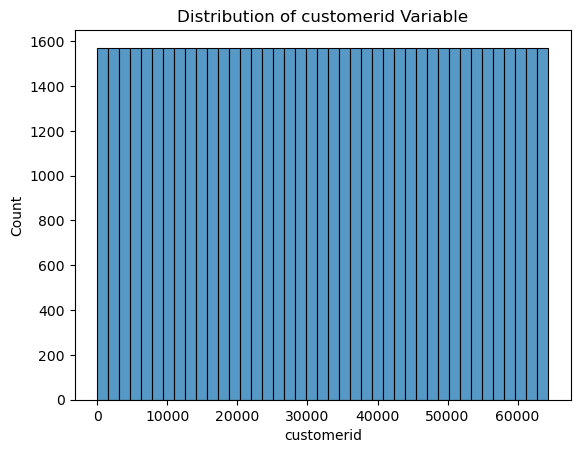

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


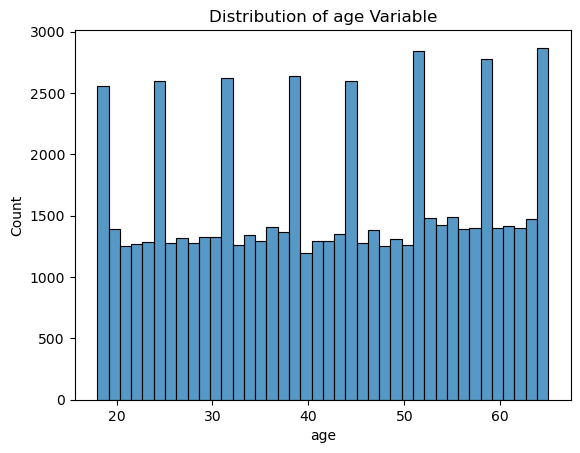

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


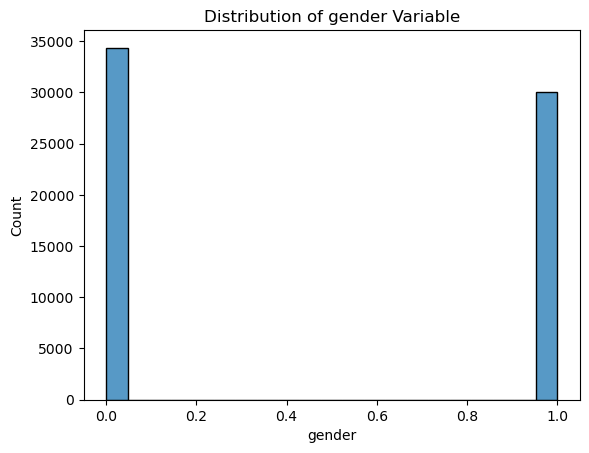

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


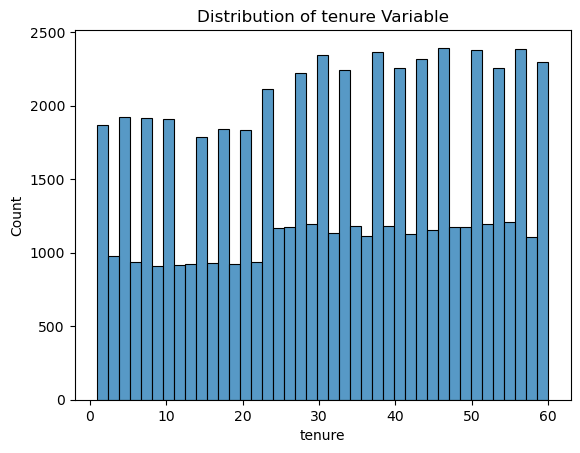

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


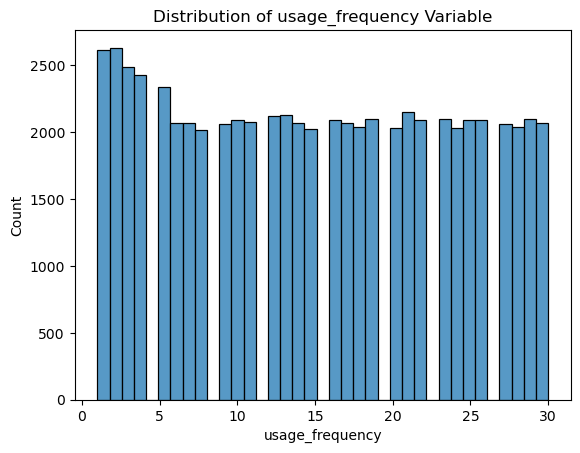

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


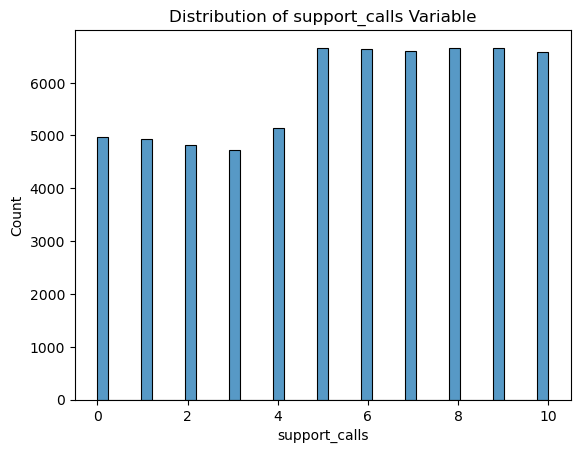

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


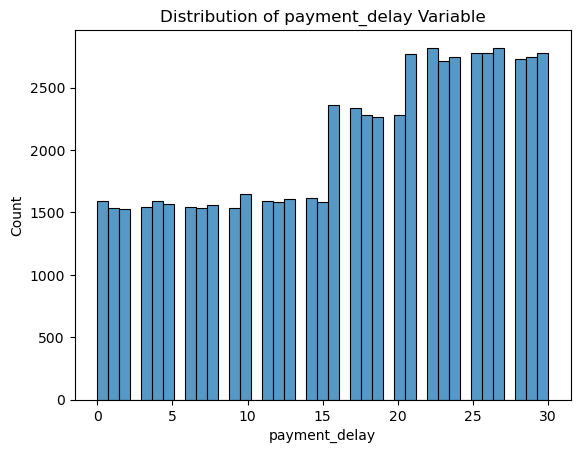

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


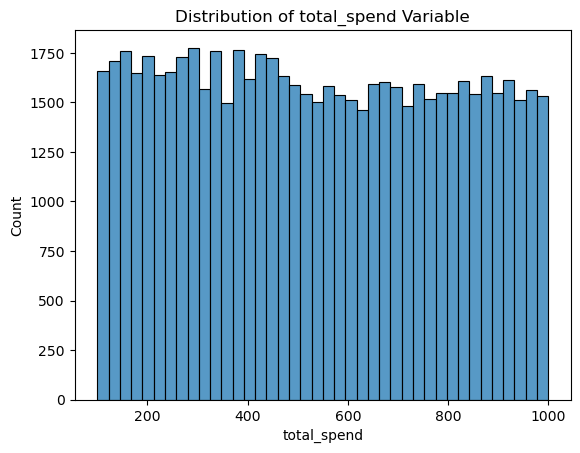

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


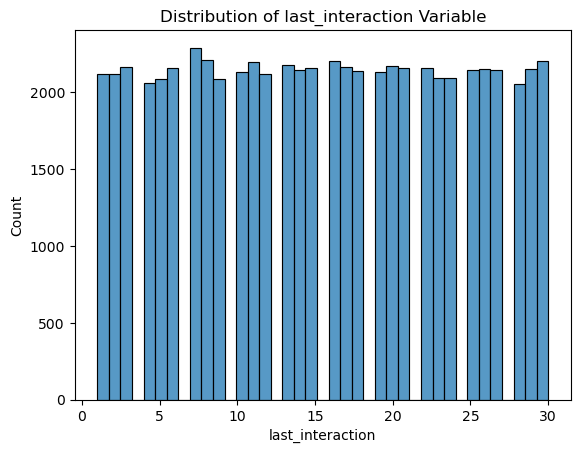

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


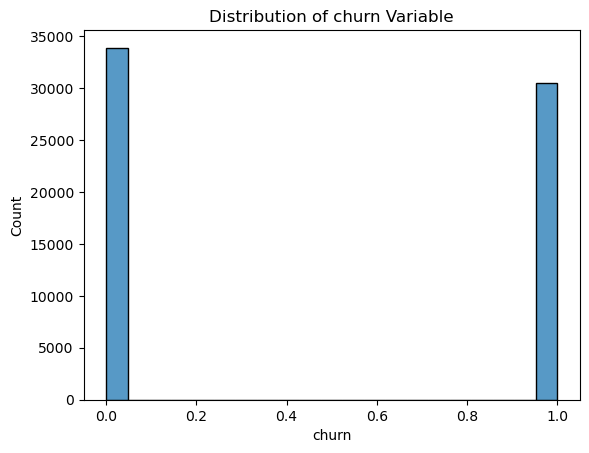

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


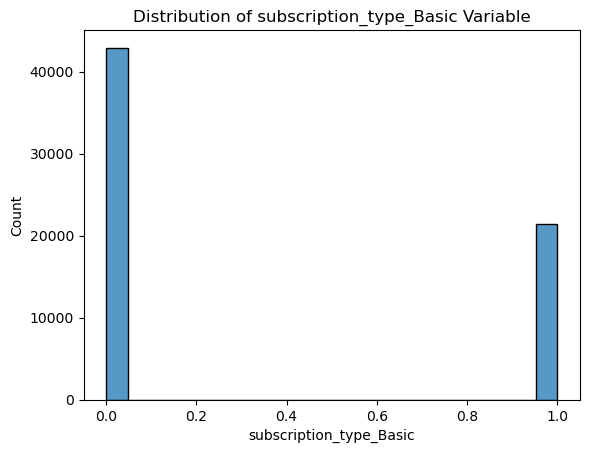

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


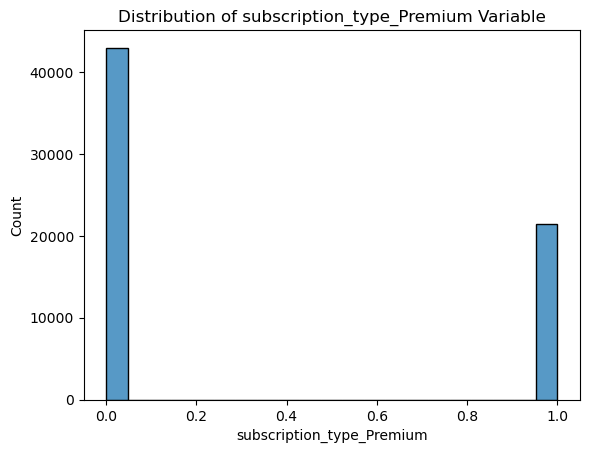

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


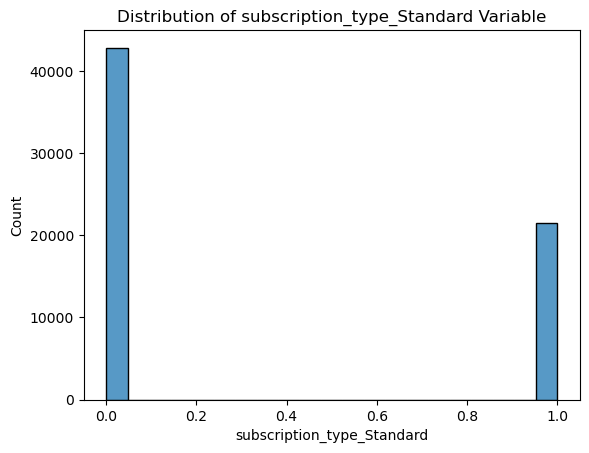

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


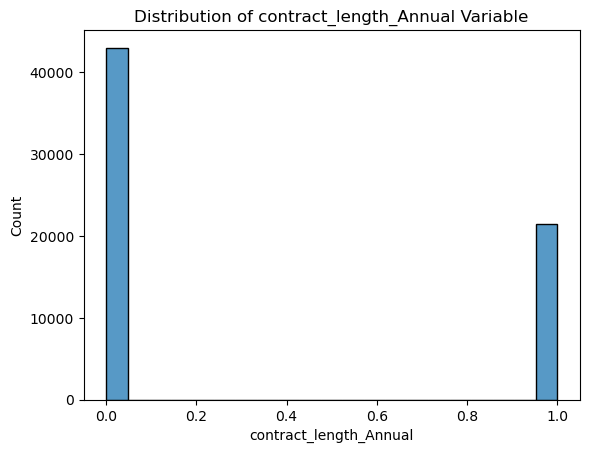

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


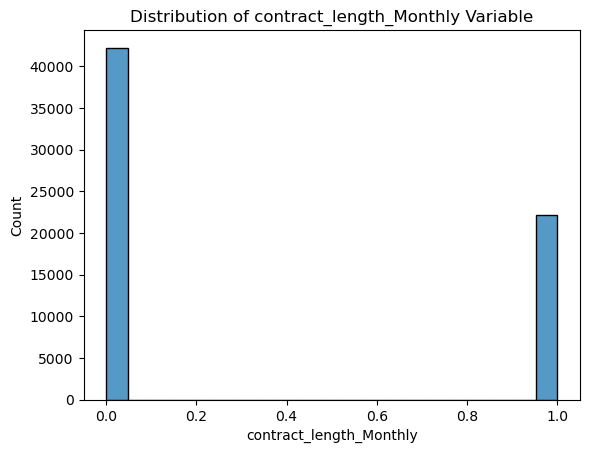

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


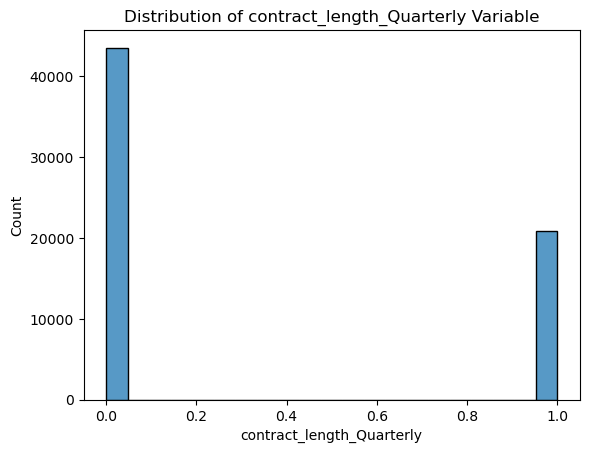

In [19]:
for column in test_data.columns:
    sns.histplot(
        data = test_data,
        x = column
    )
    plt.title(f"Distribution of {column} Variable")
    plt.show()

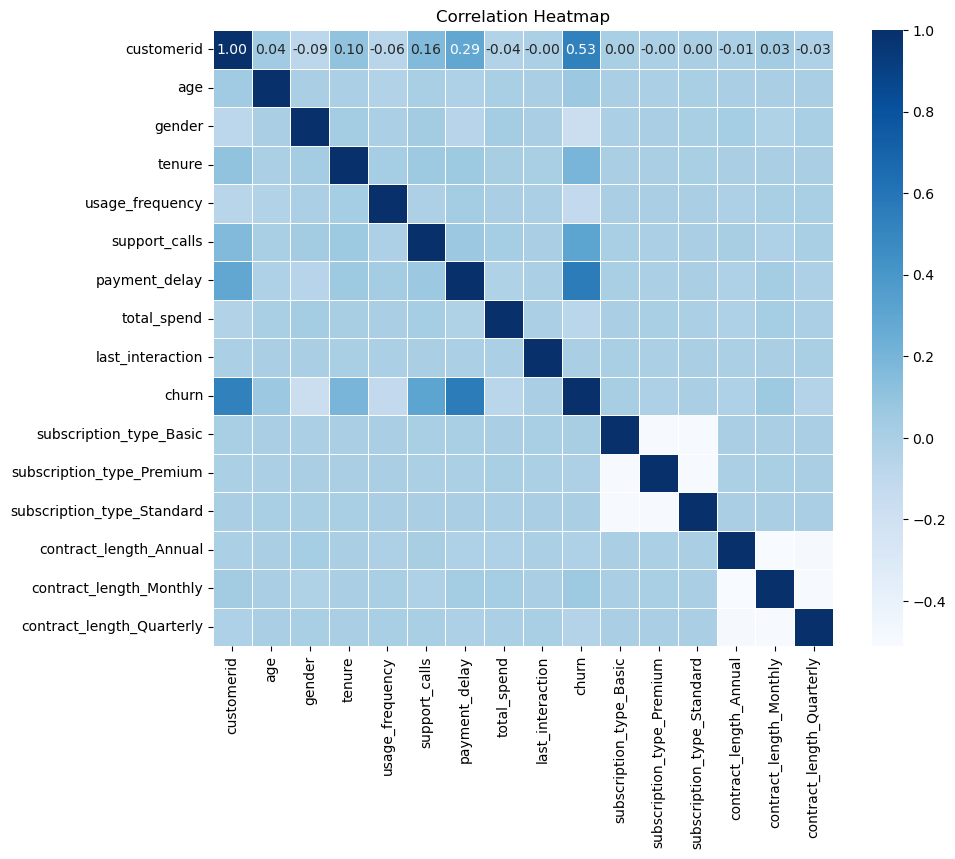

In [20]:
corr = test_data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

In [21]:
data.to_csv("train_data.csv")
test_data.to_csv("test_data.csv")

# Part 2: Machine Learning Model

In [48]:
train_data = pd.read_csv("train_data.csv", index_col=0)
test_data = pd.read_csv("test_data.csv", index_col=0)

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x = train_data.drop(["churn","customerid"], axis=1)
y = train_data["churn"]


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

sc = StandardScaler()

X_train = sc.fit_transform(x_train)
X_test = sc.transform(x_test)

In [50]:
from sklearn.linear_model import LogisticRegression

logr = LogisticRegression(random_state=0)
logr.fit(X_train,y_train)

LogisticRegression(random_state=0)

In [51]:
y_pred = logr.predict(X_test)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[51686,  5467],
       [ 8430, 66667]], dtype=int64)

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")

Accuracy : 0.895
Precision: 0.924
Recall   : 0.888
F1-score : 0.906


In [54]:
y_pred = logr.predict(test_data.drop(["churn","customerid"], axis=1))
y_test = test_data["churn"]

cm = confusion_matrix(y_pred, y_test)
cm

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


array([[33881, 30493],
       [    0,     0]], dtype=int64)

In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")

Accuracy : 0.526
Precision: 0.000
Recall   : 0.000
F1-score : 0.000


C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Part 3: What is Wrong About Our Data (after the result of the model)

### Chi-Square Test for Label Drift

In [56]:
def target_distribution(y, name):
    dist = y.value_counts(normalize=True).sort_index()
    print(f"\n{name} target distribution:")
    print(dist)
    return dist


Train target distribution:
churn
0    0.432893
1    0.567107
Name: proportion, dtype: float64

Test target distribution:
churn
0    0.526315
1    0.473685
Name: proportion, dtype: float64


<Axes: title={'center': 'Target Distribution: Train vs Test'}, xlabel='churn'>

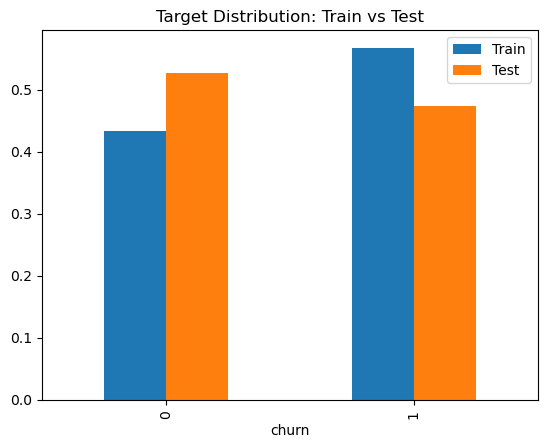

In [57]:
y_train = train_data["churn"]
y_test  = test_data["churn"]

train_dist = target_distribution(y_train, "Train")
test_dist  = target_distribution(y_test, "Test")

dist_df = pd.DataFrame({
    "Train": train_dist,
    "Test": test_dist
})

dist_df.plot(kind="bar", title="Target Distribution: Train vs Test")

In [58]:
from scipy.stats import chi2_contingency

contingency_table = pd.concat([
    y_train.value_counts(),
    y_test.value_counts()
], axis=1).fillna(0)

contingency_table.columns = ["Train", "Test"]

chi2, p, _, _ = chi2_contingency(contingency_table)

print("Chi-square p-value:", p)

Chi-square p-value: 0.0


### Kolmogrov-Smirov Test for Data Drift

In [59]:
from scipy.stats import ks_2samp

results = []

for col in train_data.columns:
    stat, p = ks_2samp(train_data[col], test_data[col])
    alpha = 0.05

    results.append({
        "variable": col,
        "ks_statistic": stat,
        "p_value": p,
        "h0_decision": "H0 rejected" if p < alpha else "H0 not rejected"
    })

ks_results = pd.DataFrame(results)
ks_results

,variable,ks_statistic,p_value,h0_decision
0,customerid,0.857100,0.000000e+00,H0 rejected
1,age,0.146553,0.000000e+00,H0 rejected
2,gender,0.101328,0.000000e+00,H0 rejected
3,tenure,0.025948,2.740202e-33,H0 rejected
4,usage_frequency,0.042062,8.594274e-87,H0 rejected
5,support_calls,0.292820,0.000000e+00,H0 rejected
6,payment_delay,0.239355,0.000000e+00,H0 rejected
7,total_spend,0.201455,0.000000e+00,H0 rejected
8,last_interaction,0.067633,7.637327e-224,H0 rejected
9,churn,0.093422,0.000000e+00,H0 rejected


### Feature Importance

In [60]:
from sklearn.inspection import permutation_importance

x = train_data.drop(columns=["churn"])
y = train_data["churn"]

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3, stratify=y, random_state=0)
X_train = sc.fit_transform(x_train)
X_val = sc.transform(x_val)

logr = LogisticRegression(random_state=0)
logr.fit(X_train,y_train)

perm_result = permutation_importance(
    logr,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature": x_train.columns,
    "importance": perm_result.importances_mean
}).sort_values("importance", ascending=False)

perm_df.head(10)

,feature,importance
0,customerid,0.187415
13,contract_length_Monthly,0.015927
5,support_calls,0.011216
7,total_spend,0.003027
12,contract_length_Annual,0.002787
14,contract_length_Quarterly,0.002546
6,payment_delay,0.001189
2,gender,0.000391
8,last_interaction,0.000350
1,age,0.000324


After observing a large performance gap between validation results and the provided test set, I focused on understanding whether this issue was caused by the model or by data-related factors.

First, a chi-square test was applied to the target variable to check for label drift, which showed that the churn distribution differs significantly between the train and test datasets. This alone explains part of the performance drop on the test set.

Next, data drift was analyzed using the Kolmogorov–Smirnov test for each feature. The results indicated noticeable distribution shifts in several key behavioral features, such as support calls, payment delays, and total spending. These shifts suggest that the train and test datasets do not represent the same underlying population.

Finally, feature importance analysis was used to understand which variables the model relied on most. This step also helped identify and remove non-informative or identifier-like features, reducing the risk of data leakage and overfitting.

Overall, the results show that the main challenge in this project is not model selection, but dataset shift. This highlights the importance of validating data consistency and feature behavior, especially when working with pre-split datasets.